# Semi-Supervised Fraud Detection Experiment

This notebook tests whether semi-supervised methods add useful signal beyond the current hybrid baseline.

It preserves the same leakage-safe feature engineering used in notebook 03:
- event-level fraud matching via `draw_id|member_id`
- pre-fraud-only history for known fraud players
- the same player-level feature matrix for a fair comparison

It reports two views separately:
- **Evidence**: masked-seed recovery of held-out fraud players
- **Operations**: full-cohort ranking for alerting

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import entropy as scipy_entropy
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_SEED = 42
DATA_DIR = Path("../data_cache")
PARQUET = DATA_DIR / "fraud_modeling_pull.parquet"
FRAUD_CSV = Path("../ROULET CHEATING DATA.csv")
SAVED_PT = DATA_DIR / "player_feature_table.parquet"
HYBRID_SCORES = DATA_DIR / "hybrid_scored_players.parquet"
HYBRID_EVAL = DATA_DIR / "hybrid_evaluation.json"

THRESHOLDS = [0.01, 0.05, 0.10, 0.20]
MASKED_RUNS = 20

In [2]:
roulette_df = pd.read_parquet(PARQUET)
fraud_csv = pd.read_csv(FRAUD_CSV)
fraud_csv.columns = [c.strip().lower() for c in fraud_csv.columns]

required_fraud_cols = {"draw_id", "member_id", "ccs_id"}
missing_fraud_cols = required_fraud_cols - set(fraud_csv.columns)
if missing_fraud_cols:
    raise ValueError(f"Fraud CSV is missing required columns: {sorted(missing_fraud_cols)}")

fraud_csv["member_id_norm"] = fraud_csv["member_id"].astype(str).str.strip().str.upper()
fraud_csv["draw_id_norm"] = pd.to_numeric(fraud_csv["draw_id"], errors="coerce").astype("Int64")
fraud_csv["fraud_event_key"] = fraud_csv["draw_id_norm"].astype(str) + "|" + fraud_csv["member_id_norm"]

roulette_df["member_id"] = roulette_df["member_id"].astype(str).str.strip().str.upper()
roulette_df["draw_id"] = pd.to_numeric(roulette_df["draw_id"], errors="coerce").astype("Int64")
roulette_df["fraud_event_key"] = roulette_df["draw_id"].astype(str) + "|" + roulette_df["member_id"]

ts_col = next(
    (col for col in ["createdAt.$date", "createdat.$date", "trans_date.$date", "updatedAt.$date", "ts"] if col in roulette_df.columns),
    None,
)
if ts_col is not None:
    roulette_df["ts"] = pd.to_datetime(roulette_df[ts_col], utc=True, errors="coerce")
else:
    roulette_df["ts"] = pd.NaT

def parse_bets(raw):
    if isinstance(raw, list):
        return raw
    if isinstance(raw, str):
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return []
    return []

roulette_df["bets_parsed"] = roulette_df["bets"].apply(parse_bets)
matched_events = int(roulette_df["fraud_event_key"].isin(set(fraud_csv["fraud_event_key"])).sum())
bet_lengths = roulette_df["bets_parsed"].apply(len)
empty_bet_rows = int((bet_lengths == 0).sum())

print(f"Parquet shape       : {roulette_df.shape}")
print(f"Fraud CSV rows      : {len(fraud_csv)}, unique members: {fraud_csv['member_id_norm'].nunique()}")
print(f"Parquet members     : {roulette_df['member_id'].nunique()}")
print(f"Matched event keys  : {matched_events}")
print(f"Null timestamps     : {roulette_df['ts'].isna().sum()}")
print(f"Rows with empty bets: {empty_bet_rows}")
print("Extract scope       : analysis cohort only, not the full platform population")

Parquet shape       : (48385, 29)
Fraud CSV rows      : 437, unique members: 402
Parquet members     : 1049
Matched event keys  : 21
Null timestamps     : 65
Rows with empty bets: 0
Extract scope       : analysis cohort only, not the full platform population


In [3]:
def safe_entropy(amounts):
    values = np.array([a for a in amounts if a > 0], dtype=float)
    if values.sum() == 0:
        return 0.0
    probs = values / values.sum()
    return float(scipy_entropy(probs, base=2))


def gini_coeff(amounts):
    values = np.sort(np.array([a for a in amounts if a > 0], dtype=float))
    count = len(values)
    if count == 0 or values.sum() == 0:
        return 0.0
    idx = np.arange(1, count + 1)
    return float((2 * np.sum(idx * values) / (count * values.sum())) - (count + 1) / count)


def make_bet_template(bets_list):
    if not isinstance(bets_list, list):
        return tuple()
    return tuple(sorted(
        (str(bet.get("number", "")), round(float(bet.get("bet_amount", 0) or 0), 6))
        for bet in bets_list
        if float(bet.get("bet_amount", 0) or 0) > 0
    ))


def compute_draw_features(bets_list):
    amounts = [float(bet.get("bet_amount", 0) or 0) for bet in bets_list]
    nonzero = [amount for amount in amounts if amount > 0]
    total_amount = sum(amounts)
    max_amount = max(amounts) if amounts else 0.0
    nonzero_count = len(nonzero)
    return {
        "bets_per_draw": len(amounts),
        "nonzero_bets_per_draw": nonzero_count,
        "tiny_bet_ratio_in_draw": sum(1 for amount in nonzero if amount <= 1) / max(nonzero_count, 1),
        "max_bet_share_in_draw": max_amount / total_amount if total_amount > 0 else 0.0,
        "bet_amount_std_in_draw": float(np.std(nonzero)) if nonzero_count > 1 else 0.0,
        "bet_amount_mean_in_draw": float(np.mean(nonzero)) if nonzero_count > 0 else 0.0,
        "entropy_in_draw": safe_entropy(amounts),
        "gini_in_draw": max(gini_coeff(amounts), 0.0),
        "unique_positions_in_draw": nonzero_count,
        "position_coverage": nonzero_count / 38.0,
    }


draw_feat_df = pd.DataFrame(roulette_df["bets_parsed"].apply(compute_draw_features).tolist())
roulette_df = pd.concat([roulette_df, draw_feat_df], axis=1)
roulette_df["net_result"] = roulette_df["win_points"] - roulette_df["total_bet_amount"]
roulette_df["bet_template"] = roulette_df["bets_parsed"].apply(make_bet_template)

roulette_df_sorted = roulette_df.sort_values(["member_id", "ts"])
roulette_df["inter_draw_seconds"] = roulette_df_sorted.groupby("member_id")["ts"].diff().dt.total_seconds()

check_row = roulette_df.iloc[2]
expected_entropy = safe_entropy([float(b.get("bet_amount", 0) or 0) for b in check_row["bets_parsed"]])
assert abs(check_row["entropy_in_draw"] - expected_entropy) < 1e-9
assert roulette_df["nonzero_bets_per_draw"].between(0, 38).all()
assert roulette_df["gini_in_draw"].between(0, 1.01).all()

print("Draw-level feature engineering complete")
display(
    roulette_df[[
        "nonzero_bets_per_draw",
        "entropy_in_draw",
        "gini_in_draw",
        "max_bet_share_in_draw",
        "position_coverage",
    ]].describe().round(4)
)

Draw-level feature engineering complete


,nonzero_bets_per_draw,entropy_in_draw,gini_in_draw,max_bet_share_in_draw,position_coverage
count,"48,385.0000","48,385.0000","48,385.0000","48,385.0000","48,385.0000"
mean,18.7708,3.7724,0.2022,0.1522,0.4940
std,9.3815,1.0580,0.1629,0.1524,0.2469
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,12.0000,3.3477,0.0429,0.0559,0.3158
50%,18.0000,4.0772,0.1957,0.1081,0.4737
75%,24.0000,4.3962,0.3149,0.1818,0.6316
max,38.0000,5.2436,0.9236,1.0000,1.0000


In [4]:
fraud_event_keys = set(fraud_csv["fraud_event_key"])
roulette_df["event_label"] = roulette_df["fraud_event_key"].isin(fraud_event_keys).astype(int)

event_match_df = roulette_df.loc[roulette_df["event_label"] == 1, ["member_id", "draw_id", "ts"]].copy()
first_fraud = (
    event_match_df.sort_values(["member_id", "ts", "draw_id"])
    .groupby("member_id", as_index=False)
    .agg(
        first_fraud_ts=("ts", "min"),
        first_fraud_draw_id=("draw_id", "min"),
        matched_fraud_rows=("draw_id", "size"),
    )
)
fraud_player_set = set(first_fraud["member_id"])

roulette_df = roulette_df.merge(
    first_fraud[["member_id", "first_fraud_ts", "first_fraud_draw_id"]].assign(is_fraud_player=1),
    on="member_id",
    how="left",
)
roulette_df["is_fraud_player"] = roulette_df["is_fraud_player"].fillna(0).astype(int)

pre_fraud_mask = (
    roulette_df["is_fraud_player"].eq(1)
    & (
        (
            roulette_df["ts"].notna()
            & roulette_df["first_fraud_ts"].notna()
            & (roulette_df["ts"] < roulette_df["first_fraud_ts"])
        )
        | (
            roulette_df["first_fraud_ts"].isna()
            & roulette_df["first_fraud_draw_id"].notna()
            & (roulette_df["draw_id"] < roulette_df["first_fraud_draw_id"])
        )
    )
)
non_fraud_mask = roulette_df["is_fraud_player"].eq(0)
history_df = roulette_df[pre_fraud_mask | non_fraud_mask].copy()

eligible_positive_players = int(history_df.loc[history_df["member_id"].isin(fraud_player_set), "member_id"].nunique())
dropped_positive_players = int(len(fraud_player_set) - eligible_positive_players)

print(f"Matched fraud event rows                  : {int(roulette_df['event_label'].sum())}")
print(f"Fraud players with matched events         : {len(fraud_player_set)}")
print(f"Usable fraud players after cutoff         : {eligible_positive_players}")
print(f"Dropped fraud players with no pre-history : {dropped_positive_players}")
print(f"History rows retained                     : {len(history_df):,}")

Matched fraud event rows                  : 21
Fraud players with matched events         : 18
Usable fraud players after cutoff         : 14
Dropped fraud players with no pre-history : 4
History rows retained                     : 44,794


In [5]:
def mode_val(series):
    modes = series.mode()
    return modes.iloc[0] if len(modes) else np.nan


player_agg = history_df.groupby("member_id").agg(
    draws_played=("draw_id", "nunique"),
    sessions_played=("session_id", "nunique"),
    active_days=("ts", lambda x: x.dt.date.nunique()),
    total_staked=("total_bet_amount", "sum"),
    avg_stake_per_draw=("total_bet_amount", "mean"),
    median_stake_per_draw=("total_bet_amount", "median"),
    stake_std=("total_bet_amount", "std"),
    max_stake_per_draw=("total_bet_amount", "max"),
    min_stake_per_draw=("total_bet_amount", "min"),
    avg_inter_draw_seconds=("inter_draw_seconds", "mean"),
    std_inter_draw_seconds=("inter_draw_seconds", "std"),
    median_inter_draw_seconds=("inter_draw_seconds", "median"),
    min_inter_draw_seconds=("inter_draw_seconds", "min"),
    avg_nonzero_bets_per_draw=("nonzero_bets_per_draw", "mean"),
    median_nonzero_bets_per_draw=("nonzero_bets_per_draw", "median"),
    avg_max_bet_share=("max_bet_share_in_draw", "mean"),
    median_max_bet_share=("max_bet_share_in_draw", "median"),
    avg_bet_amount_std_in_draw=("bet_amount_std_in_draw", "mean"),
    avg_bet_amount_mean_in_draw=("bet_amount_mean_in_draw", "mean"),
    avg_entropy=("entropy_in_draw", "mean"),
    entropy_std=("entropy_in_draw", "std"),
    avg_gini=("gini_in_draw", "mean"),
    gini_std=("gini_in_draw", "std"),
    avg_tiny_bet_ratio=("tiny_bet_ratio_in_draw", "mean"),
    avg_position_coverage=("position_coverage", "mean"),
    unique_templates=("bet_template", "nunique"),
    avg_net_result=("net_result", "mean"),
    median_net_result=("net_result", "median"),
    std_net_result=("net_result", "std"),
    total_net_result=("net_result", "sum"),
    positive_draw_rate=("net_result", lambda x: (x > 0).mean()),
    primary_ccs_id=("ccs_id", mode_val),
).reset_index()

for col in ["stake_std", "entropy_std", "gini_std", "std_net_result", "std_inter_draw_seconds"]:
    player_agg[col] = player_agg[col].fillna(0)
for col in ["avg_inter_draw_seconds", "median_inter_draw_seconds", "min_inter_draw_seconds"]:
    player_agg[col] = player_agg[col].replace([np.inf, -np.inf], np.nan).fillna(0)

player_agg["stake_cv"] = (
    player_agg["stake_std"] / player_agg["avg_stake_per_draw"].replace(0, np.nan)
).fillna(0)
player_agg["template_reuse_ratio"] = (
    1 - (player_agg["unique_templates"] / player_agg["draws_played"].replace(0, np.nan))
).fillna(0).clip(lower=0)
player_agg["pnl_volatility"] = (
    player_agg["std_net_result"] / player_agg["avg_stake_per_draw"].replace(0, np.nan)
).fillna(0)
player_agg["win_rate"] = player_agg["positive_draw_rate"]
player_agg["draws_per_active_day"] = (
    player_agg["draws_played"] / player_agg["active_days"].replace(0, np.nan)
).fillna(0)

session_draws = (
    history_df.groupby(["member_id", "session_id"])["draw_id"]
    .nunique()
    .reset_index(name="draws_in_session")
)
avg_session_draws = session_draws.groupby("member_id")["draws_in_session"].mean().reset_index(name="avg_draws_per_session")
player_agg = player_agg.merge(avg_session_draws, on="member_id", how="left")
player_agg["avg_draws_per_session"] = player_agg["avg_draws_per_session"].fillna(1)

max_reuse = (
    history_df.groupby("member_id")["bet_template"]
    .apply(lambda values: values.value_counts().iloc[0] if len(values) else 1)
    .reset_index(name="max_template_reuse")
)
player_agg = player_agg.merge(max_reuse, on="member_id", how="left")

ccs_player_count = history_df.groupby("ccs_id")["member_id"].nunique().reset_index(name="ccs_player_count")
ccs_totals = (
    history_df.groupby("ccs_id")
    .agg(
        ccs_total_staked=("total_bet_amount", "sum"),
        ccs_avg_bet=("total_bet_amount", "mean"),
    )
    .reset_index()
)
player_agg = (
    player_agg
    .merge(ccs_player_count.rename(columns={"ccs_id": "primary_ccs_id"}), on="primary_ccs_id", how="left")
    .merge(ccs_totals.rename(columns={"ccs_id": "primary_ccs_id"}), on="primary_ccs_id", how="left")
)
for col in ["ccs_player_count", "ccs_total_staked", "ccs_avg_bet"]:
    player_agg[col] = player_agg[col].fillna(0)

player_agg["event_fraud_flag"] = player_agg["member_id"].isin(fraud_player_set).astype(int)
usable_positive_players = int((player_agg["event_fraud_flag"] == 1).sum())
assert usable_positive_players == eligible_positive_players
assert len(player_agg) == 1045, f"Expected 1045 players, got {len(player_agg)}"
assert usable_positive_players == 14, f"Expected 14 fraud players, got {usable_positive_players}"

saved = pd.read_parquet(SAVED_PT).rename(columns={"player_label": "event_fraud_flag"})
shared_members = set(player_agg["member_id"]) & set(saved["member_id"])
print(f"Player feature table shape           : {player_agg.shape}")
print(f"Fraud players in feature set         : {usable_positive_players}")
print(f"Dropped positive players             : {dropped_positive_players}")
print(f"Shared members vs saved artifact     : {len(shared_members)}")
print("Feature matrix matches notebook 03 cohort counts")

Player feature table shape           : (1045, 44)
Fraud players in feature set         : 14
Dropped positive players             : 4
Shared members vs saved artifact     : 1045
Feature matrix matches notebook 03 cohort counts


In [6]:
EXCLUDE_COLS = {"member_id", "event_fraud_flag", "primary_ccs_id"}
numeric_cols = [
    col for col in player_agg.columns
    if col not in EXCLUDE_COLS
    and player_agg[col].dtype in (float, int, np.float64, np.int64)
    and player_agg[col].nunique() > 1
]

LOG1P_COLS = {
    "total_staked", "avg_stake_per_draw", "median_stake_per_draw", "stake_std",
    "max_stake_per_draw", "ccs_total_staked", "ccs_avg_bet", "stake_cv",
    "avg_bet_amount_std_in_draw", "avg_bet_amount_mean_in_draw",
    "std_net_result", "pnl_volatility",
}

X_raw = player_agg[numeric_cols].copy()
for col in LOG1P_COLS:
    if col in X_raw.columns:
        X_raw[col] = np.log1p(X_raw[col].clip(lower=0))
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

y_supervised = player_agg["event_fraud_flag"].to_numpy()
y_semi = np.full(len(player_agg), -1, dtype=int)
y_semi[y_supervised == 1] = 1

if HYBRID_SCORES.exists():
    hybrid_seed_df = pd.read_parquet(HYBRID_SCORES)[["member_id", "anomaly_score"]]
    seed_df = player_agg[["member_id"]].merge(hybrid_seed_df, on="member_id", how="left")
    clean_threshold = seed_df["anomaly_score"].quantile(0.05)
    clean_mask = (seed_df["anomaly_score"] <= clean_threshold).to_numpy() & (y_supervised == 0)
    clean_seed_source = "hybrid anomaly_score bottom 5%"
else:
    iso_seed = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_SEED)
    iso_seed.fit(X_scaled)
    iso_scores = -iso_seed.score_samples(X_scaled)
    clean_threshold = np.percentile(iso_scores, 5)
    clean_mask = (iso_scores <= clean_threshold) & (y_supervised == 0)
    clean_seed_source = "fallback isolation forest bottom 5%"

y_semi_2class = np.full(len(player_agg), -1, dtype=int)
y_semi_2class[y_supervised == 1] = 1
y_semi_2class[clean_mask] = 0

print(f"Feature matrix shape     : {X_scaled.shape}")
print(f"Fraud seeds             : {(y_semi_2class == 1).sum()}")
print(f"Clean seeds             : {(y_semi_2class == 0).sum()}")
print(f"Unlabeled players       : {(y_semi_2class == -1).sum()}")
print(f"Clean seed source       : {clean_seed_source}")

Feature matrix shape     : (1045, 41)
Fraud seeds             : 14
Clean seeds             : 53
Unlabeled players       : 978
Clean seed source       : hybrid anomaly_score bottom 5%


In [7]:
def normalize_01(values):
    values = np.asarray(values, dtype=float)
    value_min = np.nanmin(values)
    value_max = np.nanmax(values)
    if not np.isfinite(value_min) or not np.isfinite(value_max) or value_max <= value_min:
        return np.zeros(len(values), dtype=float)
    return (values - value_min) / (value_max - value_min)


def graph_fraud_scores(model):
    fraud_idx = int(np.where(model.classes_ == 1)[0][0])
    return model.label_distributions_[:, fraud_idx]


def make_self_training_classifier():
    base_lr = LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED)
    try:
        return SelfTrainingClassifier(
            estimator=base_lr,
            threshold=0.75,
            criterion="threshold",
            max_iter=10,
            verbose=False,
        )
    except TypeError:
        return SelfTrainingClassifier(
            base_estimator=base_lr,
            threshold=0.75,
            criterion="threshold",
            max_iter=10,
            verbose=False,
        )


def fit_semi_supervised_scores(X_matrix, seed_labels, gamma):
    outputs = {}

    ls = LabelSpreading(kernel="rbf", gamma=gamma, alpha=0.2, max_iter=1000)
    ls.fit(X_matrix, seed_labels)
    outputs["Label Spreading"] = {
        "raw": graph_fraud_scores(ls),
        "label": ls.transduction_,
        "model": ls,
    }

    lp = LabelPropagation(kernel="rbf", gamma=gamma, max_iter=1000)
    lp.fit(X_matrix, seed_labels)
    outputs["Label Propagation"] = {
        "raw": graph_fraud_scores(lp),
        "label": lp.transduction_,
        "model": lp,
    }

    st = make_self_training_classifier()
    st.fit(X_matrix, seed_labels)
    outputs["Self-Training LR"] = {
        "raw": st.predict_proba(X_matrix)[:, 1],
        "label": st.predict(X_matrix),
        "model": st,
    }

    return outputs


def capture_counts(scores, labels, thresholds=THRESHOLDS):
    scores = pd.Series(scores)
    labels = pd.Series(labels)
    fraud_scores = scores[labels == 1]
    rows = {}
    for pct in thresholds:
        threshold = scores.quantile(1 - pct)
        rows[f"Top {int(pct * 100)}%"] = int((fraud_scores >= threshold).sum())
    return rows

In [8]:
rng = np.random.default_rng(RANDOM_SEED)
fraud_idx = np.flatnonzero(y_supervised == 1)
n_holdout = max(3, int(round(len(fraud_idx) * 0.25)))
heldout_idx = rng.choice(fraud_idx, size=n_holdout, replace=False)
heldout_mask = np.zeros(len(player_agg), dtype=bool)
heldout_mask[heldout_idx] = True

y_masked_train = y_semi_2class.copy()
y_masked_train[heldout_mask] = -1

gamma_results = []
for gamma in [1, 5, 10, 20, 50, 100]:
    ls_temp = LabelSpreading(kernel="rbf", gamma=gamma, alpha=0.2, max_iter=1000)
    ls_temp.fit(X_scaled, y_masked_train)
    temp_scores = graph_fraud_scores(ls_temp)
    heldout_mean = float(temp_scores[heldout_mask].mean())
    overall_mean = float(temp_scores.mean())
    gamma_results.append({
        "gamma": gamma,
        "heldout_fraud_score_mean": heldout_mean,
        "all_score_mean": overall_mean,
        "n_predicted_fraud": int((ls_temp.transduction_ == 1).sum()),
        "separation": heldout_mean / max(overall_mean, 1e-9),
    })

gamma_df = pd.DataFrame(gamma_results)
best_gamma = int(gamma_df.loc[gamma_df["separation"].idxmax(), "gamma"])
print(f"Selected gamma for graph methods: {best_gamma}")
display(gamma_df)

Selected gamma for graph methods: 20


,gamma,heldout_fraud_score_mean,all_score_mean,n_predicted_fraud,separation
0,1,0.5328,0.2489,260,2.1410
1,5,0.5000,0.2046,213,2.4440
2,10,0.5000,0.1982,206,2.5226
3,20,0.5000,0.1842,191,2.7145
4,50,0.2500,0.1027,108,2.4353
5,100,0.0000,0.0566,59,0.0000


In [9]:
full_outputs = fit_semi_supervised_scores(X_scaled, y_semi_2class, best_gamma)
score_col_map = {}
for method_name, result in full_outputs.items():
    col_name = method_name.lower().replace(" ", "_").replace("-", "_") + "_score"
    norm_col = col_name + "_norm"
    player_agg[col_name] = result["raw"]
    player_agg[norm_col] = normalize_01(result["raw"])
    score_col_map[method_name] = norm_col

operational_rows = []
for method_name, score_col in score_col_map.items():
    row = {"Method": method_name}
    for pct, caught in capture_counts(player_agg[score_col], y_supervised).items():
        row[pct] = f"{caught}/{int(y_supervised.sum())}"
    operational_rows.append(row)

semi_operational = pd.DataFrame(operational_rows).set_index("Method")
print("Semi-supervised full-cohort ranking capture:")
display(semi_operational)
print("NOTE: seeded fraud players are part of training here, so this is operational only.")

Semi-supervised full-cohort ranking capture:


,Top 1%,Top 5%,Top 10%,Top 20%
Method,,,,
Label Spreading,13/14,13/14,13/14,14/14
Label Propagation,14/14,14/14,14/14,14/14
Self-Training LR,3/14,3/14,4/14,12/14


NOTE: seeded fraud players are part of training here, so this is operational only.


In [10]:
masked_results = []
for seed in range(MASKED_RUNS):
    rng = np.random.default_rng(seed)
    heldout_idx = rng.choice(fraud_idx, size=n_holdout, replace=False)
    heldout_mask = np.zeros(len(player_agg), dtype=bool)
    heldout_mask[heldout_idx] = True

    y_masked_train = y_semi_2class.copy()
    y_masked_train[heldout_mask] = -1

    masked_outputs = fit_semi_supervised_scores(X_scaled, y_masked_train, best_gamma)
    for method_name, result in masked_outputs.items():
        row = {"seed": seed, "Method": method_name, "heldout_count": int(heldout_mask.sum())}
        scores = pd.Series(result["raw"])
        heldout_scores = scores[heldout_mask]
        for pct in THRESHOLDS:
            threshold = scores.quantile(1 - pct)
            row[f"Top {int(pct * 100)}%"] = float((heldout_scores >= threshold).sum() / max(heldout_mask.sum(), 1))
        masked_results.append(row)

masked_eval_long = pd.DataFrame(masked_results)
masked_eval = (
    masked_eval_long
    .groupby("Method")[["Top 1%", "Top 5%", "Top 10%", "Top 20%"]]
    .mean()
    .round(3)
)
print("Masked-seed recovery: mean held-out fraud recall")
display(masked_eval)

Masked-seed recovery: mean held-out fraud recall


,Top 1%,Top 5%,Top 10%,Top 20%
Method,,,,
Label Propagation,0.3120,0.3120,0.3120,0.3250
Label Spreading,0.3500,0.3500,0.3620,0.4000
Self-Training LR,0.1120,0.1880,0.2000,0.7000


In [11]:
hybrid_scores = pd.read_parquet(HYBRID_SCORES)[["member_id", "anomaly_score", "supervised_score_eval", "risk_score_eval"]]
player_agg = player_agg.merge(hybrid_scores, on="member_id", how="left")

comparison = player_agg.copy()
all_methods = [
    ("Hybrid combined (nb03)", "risk_score_eval"),
    ("Hybrid anomaly only (nb03)", "anomaly_score"),
    ("Hybrid supervised only (nb03)", "supervised_score_eval"),
    ("Label Spreading", score_col_map["Label Spreading"]),
    ("Label Propagation", score_col_map["Label Propagation"]),
    ("Self-Training LR", score_col_map["Self-Training LR"]),
]

operational_comparison_rows = []
for method_name, score_col in all_methods:
    row = {"Method": method_name}
    for pct, caught in capture_counts(comparison[score_col], comparison["event_fraud_flag"]).items():
        row[pct] = f"{caught}/{int(comparison['event_fraud_flag'].sum())}"
    operational_comparison_rows.append(row)
full_comparison = pd.DataFrame(operational_comparison_rows).set_index("Method")
print("HEAD-TO-HEAD: Operational ranking comparison")
display(full_comparison)

with open(HYBRID_EVAL, "r", encoding="utf-8") as f:
    hybrid_eval = json.load(f)
hybrid_fraud_n = int(hybrid_eval["fraud_players"])

def hybrid_frac(method_key, pct_key):
    return round(hybrid_eval["capture_rates"][method_key][pct_key] / hybrid_fraud_n, 3)

evidence_comparison = masked_eval.copy()
evidence_comparison.loc["Hybrid combined (nb03 OOS)"] = [
    hybrid_frac("combined_oos", "top_1pct"),
    hybrid_frac("combined_oos", "top_5pct"),
    hybrid_frac("combined_oos", "top_10pct"),
    hybrid_frac("combined_oos", "top_20pct"),
]
evidence_comparison.loc["Hybrid anomaly only (nb03 OOS)"] = [
    hybrid_frac("anomaly", "top_1pct"),
    hybrid_frac("anomaly", "top_5pct"),
    hybrid_frac("anomaly", "top_10pct"),
    hybrid_frac("anomaly", "top_20pct"),
]
evidence_comparison.loc["Hybrid supervised only (nb03 OOS)"] = [
    hybrid_frac("supervised_oos", "top_1pct"),
    hybrid_frac("supervised_oos", "top_5pct"),
    hybrid_frac("supervised_oos", "top_10pct"),
    hybrid_frac("supervised_oos", "top_20pct"),
]
evidence_order = [
    "Hybrid combined (nb03 OOS)",
    "Hybrid anomaly only (nb03 OOS)",
    "Hybrid supervised only (nb03 OOS)",
    "Label Spreading",
    "Label Propagation",
    "Self-Training LR",
]
evidence_comparison = evidence_comparison.loc[evidence_order]
print("HEAD-TO-HEAD: Evidence comparison")
display(evidence_comparison)

score_cols = [
    score_col_map["Label Spreading"],
    score_col_map["Label Propagation"],
    score_col_map["Self-Training LR"],
    "anomaly_score",
    "risk_score_eval",
]
correlation_table = comparison[score_cols].corr().round(3)
print("Score correlation matrix")
display(correlation_table)

HEAD-TO-HEAD: Operational ranking comparison


,Top 1%,Top 5%,Top 10%,Top 20%
Method,,,,
Hybrid combined (nb03),3/14,6/14,9/14,12/14
Hybrid anomaly only (nb03),3/14,6/14,7/14,10/14
Hybrid supervised only (nb03),3/14,5/14,7/14,9/14
Label Spreading,13/14,13/14,13/14,14/14
Label Propagation,14/14,14/14,14/14,14/14
Self-Training LR,3/14,3/14,4/14,12/14


HEAD-TO-HEAD: Evidence comparison


,Top 1%,Top 5%,Top 10%,Top 20%
Method,,,,
Hybrid combined (nb03 OOS),0.2140,0.4290,0.6430,0.8570
Hybrid anomaly only (nb03 OOS),0.2140,0.4290,0.5000,0.7140
Hybrid supervised only (nb03 OOS),0.2140,0.3570,0.5000,0.6430
Label Spreading,0.3500,0.3500,0.3620,0.4000
Label Propagation,0.3120,0.3120,0.3120,0.3250
Self-Training LR,0.1120,0.1880,0.2000,0.7000


Score correlation matrix


,label_spreading_score_norm,label_propagation_score_norm,self_training_lr_score_norm,anomaly_score,risk_score_eval
label_spreading_score_norm,1.0000,0.6000,0.4240,0.4040,0.5190
label_propagation_score_norm,0.6000,1.0000,0.7570,0.4810,0.5380
self_training_lr_score_norm,0.4240,0.7570,1.0000,0.4820,0.5450
anomaly_score,0.4040,0.4810,0.4820,1.0000,0.8330
risk_score_eval,0.5190,0.5380,0.5450,0.8330,1.0000


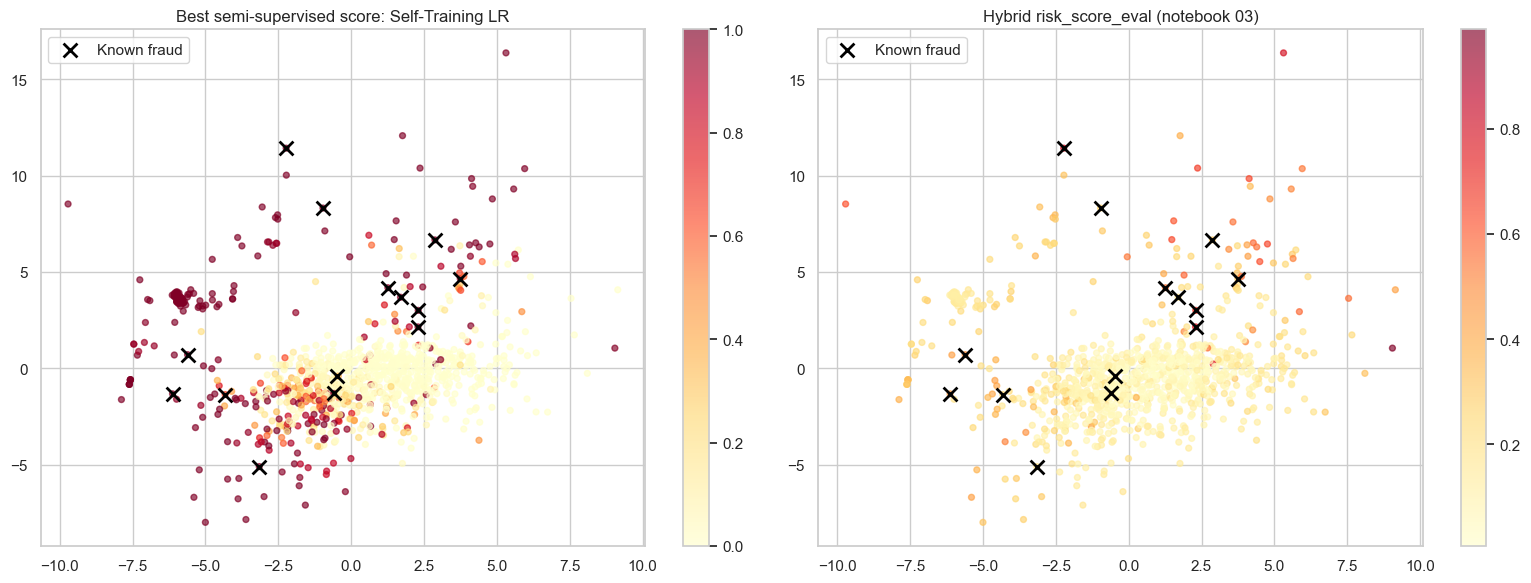

In [12]:
best_method = masked_eval["Top 20%"].sort_values(ascending=False).index[0]
best_semi_col = score_col_map[best_method]

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)
comparison["pc1"] = coords[:, 0]
comparison["pc2"] = coords[:, 1]
fraud_mask = comparison["event_fraud_flag"] == 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = axes[0].scatter(
    comparison["pc1"],
    comparison["pc2"],
    c=comparison[best_semi_col],
    cmap="YlOrRd",
    s=18,
    alpha=0.65,
)
axes[0].scatter(
    comparison.loc[fraud_mask, "pc1"],
    comparison.loc[fraud_mask, "pc2"],
    marker="x",
    s=100,
    c="black",
    linewidths=2,
    label="Known fraud",
)
axes[0].set_title(f"Best semi-supervised score: {best_method}")
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(
    comparison["pc1"],
    comparison["pc2"],
    c=comparison["risk_score_eval"],
    cmap="YlOrRd",
    s=18,
    alpha=0.65,
)
axes[1].scatter(
    comparison.loc[fraud_mask, "pc1"],
    comparison.loc[fraud_mask, "pc2"],
    marker="x",
    s=100,
    c="black",
    linewidths=2,
    label="Known fraud",
)
axes[1].set_title("Hybrid risk_score_eval (notebook 03)")
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
plt.show()

In [13]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_parquet(DATA_DIR / "semi_supervised_scored_players.parquet", index=False)
full_comparison.to_csv(DATA_DIR / "experiment_comparison.csv")
evidence_comparison.to_csv(DATA_DIR / "semi_supervised_evidence_comparison.csv")
masked_eval_long.to_csv(DATA_DIR / "semi_supervised_masked_eval_long.csv", index=False)

semi_eval_meta = {
    "total_players": int(len(comparison)),
    "fraud_players": int(comparison["event_fraud_flag"].sum()),
    "dropped_positive_players": int(dropped_positive_players),
    "clean_seed_source": clean_seed_source,
    "clean_seed_count": int((y_semi_2class == 0).sum()),
    "masked_runs": int(MASKED_RUNS),
    "masked_holdout_size": int(n_holdout),
    "best_gamma": int(best_gamma),
    "best_semi_method": best_method,
    "masked_seed_recovery": masked_eval.round(3).to_dict(orient="index"),
    "operational_capture": full_comparison.to_dict(orient="index"),
}
with open(DATA_DIR / "semi_supervised_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(semi_eval_meta, f, indent=2)

print("Saved outputs:")
print(f"  {DATA_DIR / 'semi_supervised_scored_players.parquet'}")
print(f"  {DATA_DIR / 'experiment_comparison.csv'}")
print(f"  {DATA_DIR / 'semi_supervised_evidence_comparison.csv'}")
print(f"  {DATA_DIR / 'semi_supervised_masked_eval_long.csv'}")
print(f"  {DATA_DIR / 'semi_supervised_evaluation.json'}")

Saved outputs:
  ..\data_cache\semi_supervised_scored_players.parquet
  ..\data_cache\experiment_comparison.csv
  ..\data_cache\semi_supervised_evidence_comparison.csv
  ..\data_cache\semi_supervised_masked_eval_long.csv
  ..\data_cache\semi_supervised_evaluation.json


## Conclusion Guide

Interpret the notebook in this order:

1. Use the masked-seed evidence table as the main test of whether semi-supervised learning adds lift.
2. Use the operational ranking table as a workflow view only.
3. Only treat semi-supervised as an improvement if it beats the hybrid baseline on the evidence view across more than one threshold.
4. Treat high score correlation with hybrid anomaly or combined risk as evidence that it is mostly rediscovering existing signal rather than adding new structure.

In [14]:
hybrid_top20 = evidence_comparison.loc["Hybrid combined (nb03 OOS)", "Top 20%"]
best_semi_top20 = evidence_comparison.loc[best_method, "Top 20%"]
verdict = "GREEN" if best_semi_top20 > hybrid_top20 else "NO GREEN FLAG"

print(f"Best semi-supervised method      : {best_method}")
print(f"Best semi masked Top 20% recall  : {best_semi_top20:.3f}")
print(f"Hybrid OOS Top 20% recall        : {hybrid_top20:.3f}")
print(f"Verdict                          : {verdict}")
if verdict != "GREEN":
    print("Semi-supervised did not beat the hybrid evidence baseline, so it is an informative experiment but not a replacement.")
else:
    print("Semi-supervised beat the hybrid evidence baseline and is worth deeper follow-up.")

Best semi-supervised method      : Self-Training LR
Best semi masked Top 20% recall  : 0.700
Hybrid OOS Top 20% recall        : 0.857
Verdict                          : NO GREEN FLAG
Semi-supervised did not beat the hybrid evidence baseline, so it is an informative experiment but not a replacement.
